In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
stocks = [
    "RELIANCE.NS",
    "TCS.NS",
    "HDFCBANK.NS",
    "SUNPHARMA.NS",
    "INFY.NS"
]

In [9]:
start_date = "2021-01-01"
end_date = "2025-12-31"

In [10]:
all_data = {}

for stock in stocks:
    try:
        df = yf.download(
            stock,
            start=start_date,
            end=end_date
        )

        # Check if dataframe is empty
        if df.empty:
            print(f"{stock} failed to download")
            continue

        all_data[stock] = df
        print(f"{stock} downloaded successfully")

    except Exception as e:
        print(f"Error downloading {stock}: {e}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


RELIANCE.NS downloaded successfully
TCS.NS downloaded successfully
HDFCBANK.NS downloaded successfully
SUNPHARMA.NS downloaded successfully


[*********************100%***********************]  1 of 1 completed

INFY.NS downloaded successfully


In [11]:
print(all_data.keys())

dict_keys(['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'SUNPHARMA.NS', 'INFY.NS'])


In [12]:
all_data["RELIANCE.NS"].head()

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2021-01-01,901.194641,905.502206,898.700750,901.421320,10015175
2021-01-04,902.713684,906.363760,892.352763,904.640758,24513534
2021-01-05,891.491211,899.426244,886.911511,892.806130,24123091
2021-01-06,867.980835,891.445856,863.854613,891.400520,46401468
2021-01-07,866.575073,881.923716,863.854503,870.814634,32325918


In [13]:
for stock, df in all_data.items():
    print(stock)
    print(df.shape)
    print("-" * 40)

RELIANCE.NS
(1235, 5)
----------------------------------------
TCS.NS
(1235, 5)
----------------------------------------
HDFCBANK.NS
(1235, 5)
----------------------------------------
SUNPHARMA.NS
(1235, 5)
----------------------------------------
INFY.NS
(1235, 5)
----------------------------------------


In [14]:
for stock, df in all_data.items():
    print(stock)
    print(df.isnull().sum())
    print("-" * 40)

RELIANCE.NS
Price   Ticker     
Close   RELIANCE.NS    0
High    RELIANCE.NS    0
Low     RELIANCE.NS    0
Open    RELIANCE.NS    0
Volume  RELIANCE.NS    0
dtype: int64
----------------------------------------
TCS.NS
Price   Ticker
Close   TCS.NS    0
High    TCS.NS    0
Low     TCS.NS    0
Open    TCS.NS    0
Volume  TCS.NS    0
dtype: int64
----------------------------------------
HDFCBANK.NS
Price   Ticker     
Close   HDFCBANK.NS    0
High    HDFCBANK.NS    0
Low     HDFCBANK.NS    0
Open    HDFCBANK.NS    0
Volume  HDFCBANK.NS    0
dtype: int64
----------------------------------------
SUNPHARMA.NS
Price   Ticker      
Close   SUNPHARMA.NS    0
High    SUNPHARMA.NS    0
Low     SUNPHARMA.NS    0
Open    SUNPHARMA.NS    0
Volume  SUNPHARMA.NS    0
dtype: int64
----------------------------------------
INFY.NS
Price   Ticker 
Close   INFY.NS    0
High    INFY.NS    0
Low     INFY.NS    0
Open    INFY.NS    0
Volume  INFY.NS    0
dtype: int64
----------------------------------------


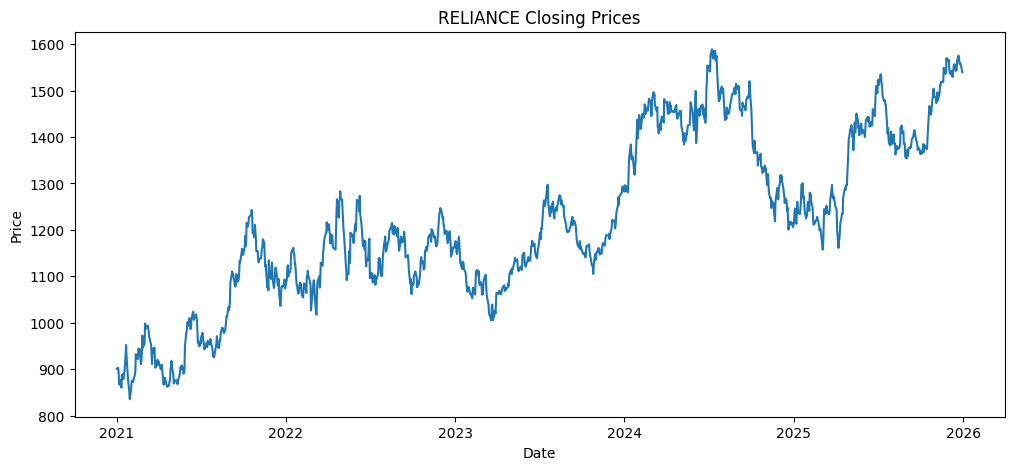

In [15]:
plt.figure(figsize=(12,5))

plt.plot(
    all_data["RELIANCE.NS"]["Close"]
)

plt.title("RELIANCE Closing Prices")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

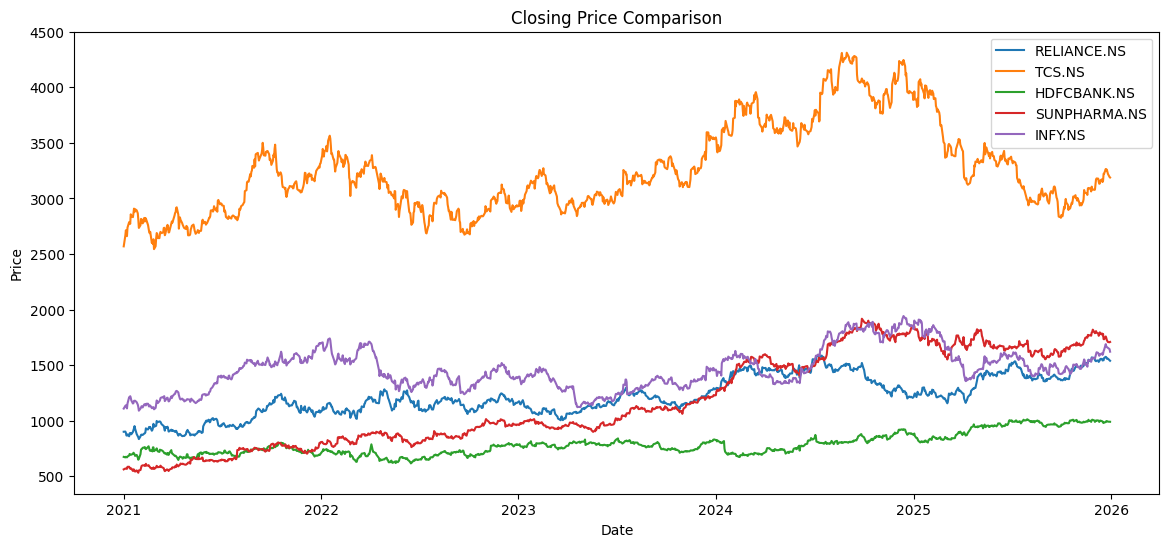

In [16]:
plt.figure(figsize=(14,6))

for stock in stocks:
    if stock in all_data:
        plt.plot(
            all_data[stock]["Close"],
            label=stock
        )

plt.legend()
plt.title("Closing Price Comparison")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

In [17]:
for stock, df in all_data.items():

    filename = stock.replace(".NS", "")

    df.to_csv(
        f"../data/raw/{filename}.csv"
    )

print("All datasets saved successfully")

All datasets saved successfully


In [18]:
import os

os.listdir("../data/raw")

['RELIANCE.csv', 'HDFCBANK.csv', 'SUNPHARMA.csv', 'TCS.csv', 'INFY.csv']